# Cron Explainer - the line renders one meaning and schedules another

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/cron-explainer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/cron-explainer/demo.ipynb)

`0 0 13 * 5` is not Friday the 13th. It fires **61 days a year** instead of 3,
because when both day fields are restricted cron takes their **union**. That is
POSIX behaviour, not a bug, and the line is perfectly valid either way.

This notebook works through five mechanisms where a cron expression schedules
something other than what it reads, and measures each one:

1. The union day rule - `0 0 13 * 5` and its x20 overrun
2. Steps that do not divide their field - `*/7` runs 9 times an hour, not 8.6
3. Daylight saving - "every 30 minutes" is 46 runs one day and 50 another
4. Fixed-time vs interval jobs - the same transition, two behaviours
5. UTC schedulers - the hour you wrote is not the hour it runs

Everything below is computed. Nothing is asserted from memory.

## Setup

`cron.py` sits next to this notebook in the repo. On Colab we clone the repo to
get it; locally the import just works.

In [1]:
from __future__ import annotations

import os
import sys

# On Colab there is no repo yet, so fetch it. Locally this is a no-op.
if not os.path.exists("cron.py"):
    os.system("git clone --depth 1 https://github.com/phoebefu6/phoebe-the-builder.git _repo >/dev/null 2>&1")
    sys.path.insert(0, os.path.join("_repo", "automation-suite/cron-explainer"))

import cron as C

print("cron.py loaded from:", os.path.dirname(C.__file__) or ".")

cron.py loaded from: /Users/phoebe.fu/claude works/fde-portfolio/automation-suite/cron-explainer


## 1. The union day rule

The rule, from POSIX and from Vixie cron's source:

```
if day-of-month is '*' or day-of-week is '*':   fire on DOM and DOW
else:                                            fire on DOM or  DOW
```

So restricting *both* day fields makes the schedule **wider**, not narrower.
`0 0 13 * 5` means "the 13th of any month, or any Friday".

In [2]:
from datetime import datetime, timedelta

YEAR = 2026
start = datetime(YEAR, 1, 1)
c = C.parse("0 0 13 * 5")

union = C._matching_days(c, start, 365)
inter = C._matching_days(c, start, 365, force_intersection=True)

print(f"'0 0 13 * 5' in {YEAR}")
print(f"  cron fires on          {len(union):>3} days")
print(f"  read as 'and'          {len(inter):>3} days   <- what people mean")
print(f"  unintended runs        {len(union) - len(inter):>3}")
print()
print("  the intended days:", ", ".join(f"{d:%d %b}" for d in inter))
print("  made of:           "
      f"{len([d for d in union if d.weekday() == 4])} Fridays + "
      f"{len([d for d in union if d.day == 13])} thirteenths")

'0 0 13 * 5' in 2026
  cron fires on           61 days
  read as 'and'            3 days   <- what people mean
  unintended runs         58

  the intended days: 13 Feb, 13 Mar, 13 Nov
  made of:           52 Fridays + 12 thirteenths


The tool says so in words, and refuses to describe it as an "and":

In [3]:
print(C.describe(c))
print()
for f in C.audit(c, "UTC", start):
    print(f"[{f.severity}] {f.code}")
    print(f"   {f.message}")
    print(f"   {f.detail}")

At 00:00, on day-of-month 13 **or** on Friday (whichever comes first - cron takes the union when both are restricted).

[MISREAD] DOM_DOW_UNION
   day-of-month and day-of-week are both restricted, so cron takes the union: it fires on either, not on both
   over 400 days this fires on 67 days; read as 'and' it would be 3


### The flag is set by a leading `*`, not by the whole field

Vixie sets its `STAR` flag when a day field *begins* with `*`. So `*/2` counts as
a star and turns the union back off - a detail that changes which days fire.

In [4]:
for expr in ["0 0 13 * 5", "0 0 */2 * 5", "0 0 13 * *", "0 0 * * 5"]:
    cc = C.parse(expr)
    rule = "OR  (union)" if cc.union_day_rule else "AND (intersection)"
    n = len(C._matching_days(cc, start, 365))
    print(f"{expr:<14} {rule:<20} {n:>3} firing days in {YEAR}")

0 0 13 * 5     OR  (union)           61 firing days in 2026
0 0 */2 * 5    AND (intersection)    26 firing days in 2026
0 0 13 * *     AND (intersection)    12 firing days in 2026
0 0 * * 5      AND (intersection)    52 firing days in 2026


## 2. A step that does not divide its field

`*/7` on the minute field expands to 0, 7, 14 ... 56 - and then the field wraps
at 60. The step does not wrap with it, so the last interval of every cycle is
**4 minutes, not 7**. "Every 7 minutes" is 9 runs an hour, not 60/7 = 8.6.

In [5]:
c7 = C.parse("*/7 * * * *")
fires = C.next_naive(c7, datetime(YEAR, 5, 1, 0, 0), 19)
gaps = [int((b - a).total_seconds() // 60) for a, b in zip(fires, fires[1:])]

print("minutes selected:", list(c7.minute.values))
print("observed gaps:   ", gaps)
print(f"\n{len(c7.minute.values)} runs an hour, not 60/7 = {60/7:.1f}")

step, wrap, last = C.step_gaps(c7.minute)
print(f"\nfinding: after minute {last} the wait is {wrap} min, not {step}")
print("clean step for comparison, '*/15':", C.step_gaps(C.parse("*/15 * * * *").minute))

minutes selected: [0, 7, 14, 21, 28, 35, 42, 49, 56]
observed gaps:    [7, 7, 7, 7, 7, 7, 7, 4, 7, 7, 7, 7, 7, 7, 7, 7, 4, 7]

9 runs an hour, not 60/7 = 8.6

finding: after minute 56 the wait is 4 min, not 7
clean step for comparison, '*/15': None


## 3. Daylight saving: "every 30 minutes" is not 48 times a day

An interval job follows the wall clock. Twice a year the wall clock is not 24
hours long, so the run count moves - in both directions.

In [6]:
TZ = "Europe/London"
interval = C.parse("*/30 * * * *")

def runs_on(day):
    got = C.fires(interval, day - timedelta(minutes=1), 60, TZ)
    return len([f for f in got if f.local.date() == day.date() and f.instant])

days = [
    ("ordinary day  (15 Jun)", datetime(YEAR, 6, 15)),
    ("clocks forward (29 Mar)", datetime(YEAR, 3, 29)),
    ("clocks back    (25 Oct)", datetime(YEAR, 10, 25)),
]
base = runs_on(days[0][1])
for label, d in days:
    n = runs_on(d)
    print(f"{label:<26} {n:>3} runs   {n - base:+d}")

ordinary day  (15 Jun)      48 runs   +0
clocks forward (29 Mar)     46 runs   -2
clocks back    (25 Oct)     50 runs   +2


## 4. The same transition, two different behaviours

Vixie cron splits jobs by whether the minute or hour field begins with `*`:

- **fixed-time** job (`30 1 * * *`) - if the clock jumps over 01:30, it is run
  once immediately after the jump; on the repeated hour it runs once, not twice.
- **interval** job (`*/30 * * * *`) - it just follows the wall clock. A skipped
  minute never runs; a repeated minute runs twice.

The crontab line does not say which one you wrote. The classification is derived.

In [7]:
for expr in ["30 1 * * *", "*/30 * * * *"]:
    cc = C.parse(expr)
    print(f"{expr:<14} -> {'interval' if cc.is_interval else 'fixed time'}")

print("\n--- clocks forward, 29 Mar (01:00 -> 02:00, so 01:30 does not exist) ---")
for expr, start_at in [("30 1 * * *", datetime(YEAR, 3, 28, 12)),
                       ("*/30 * * * *", datetime(YEAR, 3, 29, 0, 15))]:
    for f in C.fires(C.parse(expr), start_at, 8, TZ):
        if f.kind == C.NORMAL:
            continue
        ran = f"{f.instant:%H:%M UTC}" if f.instant else "NEVER RUNS"
        print(f"  {expr:<14} wall {f.local:%H:%M} -> {ran:<12} {f.note}")
        break

print("\n--- clocks back, 25 Oct (02:00 -> 01:00, so 01:30 happens twice) ---")
for expr, start_at in [("30 1 * * *", datetime(YEAR, 10, 24, 12)),
                       ("*/30 * * * *", datetime(YEAR, 10, 25, 0, 15))]:
    hits = [f for f in C.fires(C.parse(expr), start_at, 8, TZ) if f.kind != C.NORMAL]
    print(f"  {expr:<14} runs {len(hits)}x on the repeated wall clock")
    for f in hits:
        print(f"      wall {f.local:%H:%M} -> {f.instant:%H:%M UTC}")

30 1 * * *     -> fixed time
*/30 * * * *   -> interval

--- clocks forward, 29 Mar (01:00 -> 02:00, so 01:30 does not exist) ---
  30 1 * * *     wall 01:30 -> 01:00 UTC    fixed-time job: Vixie runs it once at the jump, at 02:00 local
  */30 * * * *   wall 01:00 -> NEVER RUNS   interval job: this wall-clock minute never happens, so it is skipped

--- clocks back, 25 Oct (02:00 -> 01:00, so 01:30 happens twice) ---
  30 1 * * *     runs 1x on the repeated wall clock
      wall 01:30 -> 00:30 UTC
  */30 * * * *   runs 4x on the repeated wall clock
      wall 01:00 -> 00:00 UTC
      wall 01:00 -> 01:00 UTC
      wall 01:30 -> 00:30 UTC
      wall 01:30 -> 01:30 UTC


## 5. The hour you wrote is not the hour it runs

GitHub Actions, EventBridge and Kubernetes CronJob all read cron in **UTC**.
They never hit a DST case at all - which is exactly why the local time they land
on moves by an hour across the year.

In [8]:
c9 = C.parse("0 9 * * *")
tz = C._zone(TZ)

for label, when in [("January", datetime(YEAR, 1, 10)), ("July", datetime(YEAR, 7, 10))]:
    u = C.fires(c9, when, 1, TZ, utc_scheduler=True)[0]
    l = C.fires(c9, when, 1, TZ)[0]
    print(f"{label:<8} on a UTC runner:      09:00 UTC = "
          f"{u.instant.astimezone(tz):%H:%M %Z} local")
    print(f"{'':<8} on a local-time host: 09:00 local = {l.instant:%H:%M} UTC")

January  on a UTC runner:      09:00 UTC = 09:00 GMT local
         on a local-time host: 09:00 local = 09:00 UTC
July     on a UTC runner:      09:00 UTC = 10:00 BST local
         on a local-time host: 09:00 local = 08:00 UTC


## The check that makes the fire times trustworthy

Two independent searches produce the schedule: a field-jumping algorithm that
skips whole months and days, and a scan that tests every single minute. They
share the parsed field sets and nothing else. If the calendar rollover or the
union rule were wrong in one, the outputs would diverge.

This is what caught two real bugs while building it - a horizon mismatch, and
`classify_local` calling every skipped hour a repeated one, because under PEP 495
*both* cases carry different offsets in the two folds.

In [9]:
EXPRS = ["* * * * *", "0 * * * *", "30 2 * * *", "*/7 * * * *", "0 */5 * * *",
         "0 0 13 * 5", "0 0 * * 1-5", "15,45 8-18 * * mon-fri", "0 0 29 2 *",
         "5 4 * * sun", "@daily", "@weekly", "0 0 31 * *", "59 23 28-31 * *"]

t0 = datetime(YEAR, 2, 26, 23, 51)
agree = compared = 0
for e in EXPRS:
    cc = C.parse(e)
    fast = C.next_naive(cc, t0, 15)
    slow = C.brute_naive(cc, t0, 15)
    compared += len(slow)
    agree += fast == slow
    flag = "ok " if fast == slow else "DIFF"
    print(f"  {flag} {e}")

print(f"\n{agree}/{len(EXPRS)} expressions identical, {compared} fire times compared")

  ok  * * * * *
  ok  0 * * * *
  ok  30 2 * * *
  ok  */7 * * * *
  ok  0 */5 * * *
  ok  0 0 13 * 5
  ok  0 0 * * 1-5
  ok  15,45 8-18 * * mon-fri
  ok  0 0 29 2 *
  ok  5 4 * * sun
  ok  @daily
  ok  @weekly
  ok  0 0 31 * *
  ok  59 23 28-31 * *

14/14 expressions identical, 210 fire times compared


## The picture

Six panels, every value computed at draw time.

wrote cron_audit_nb.png


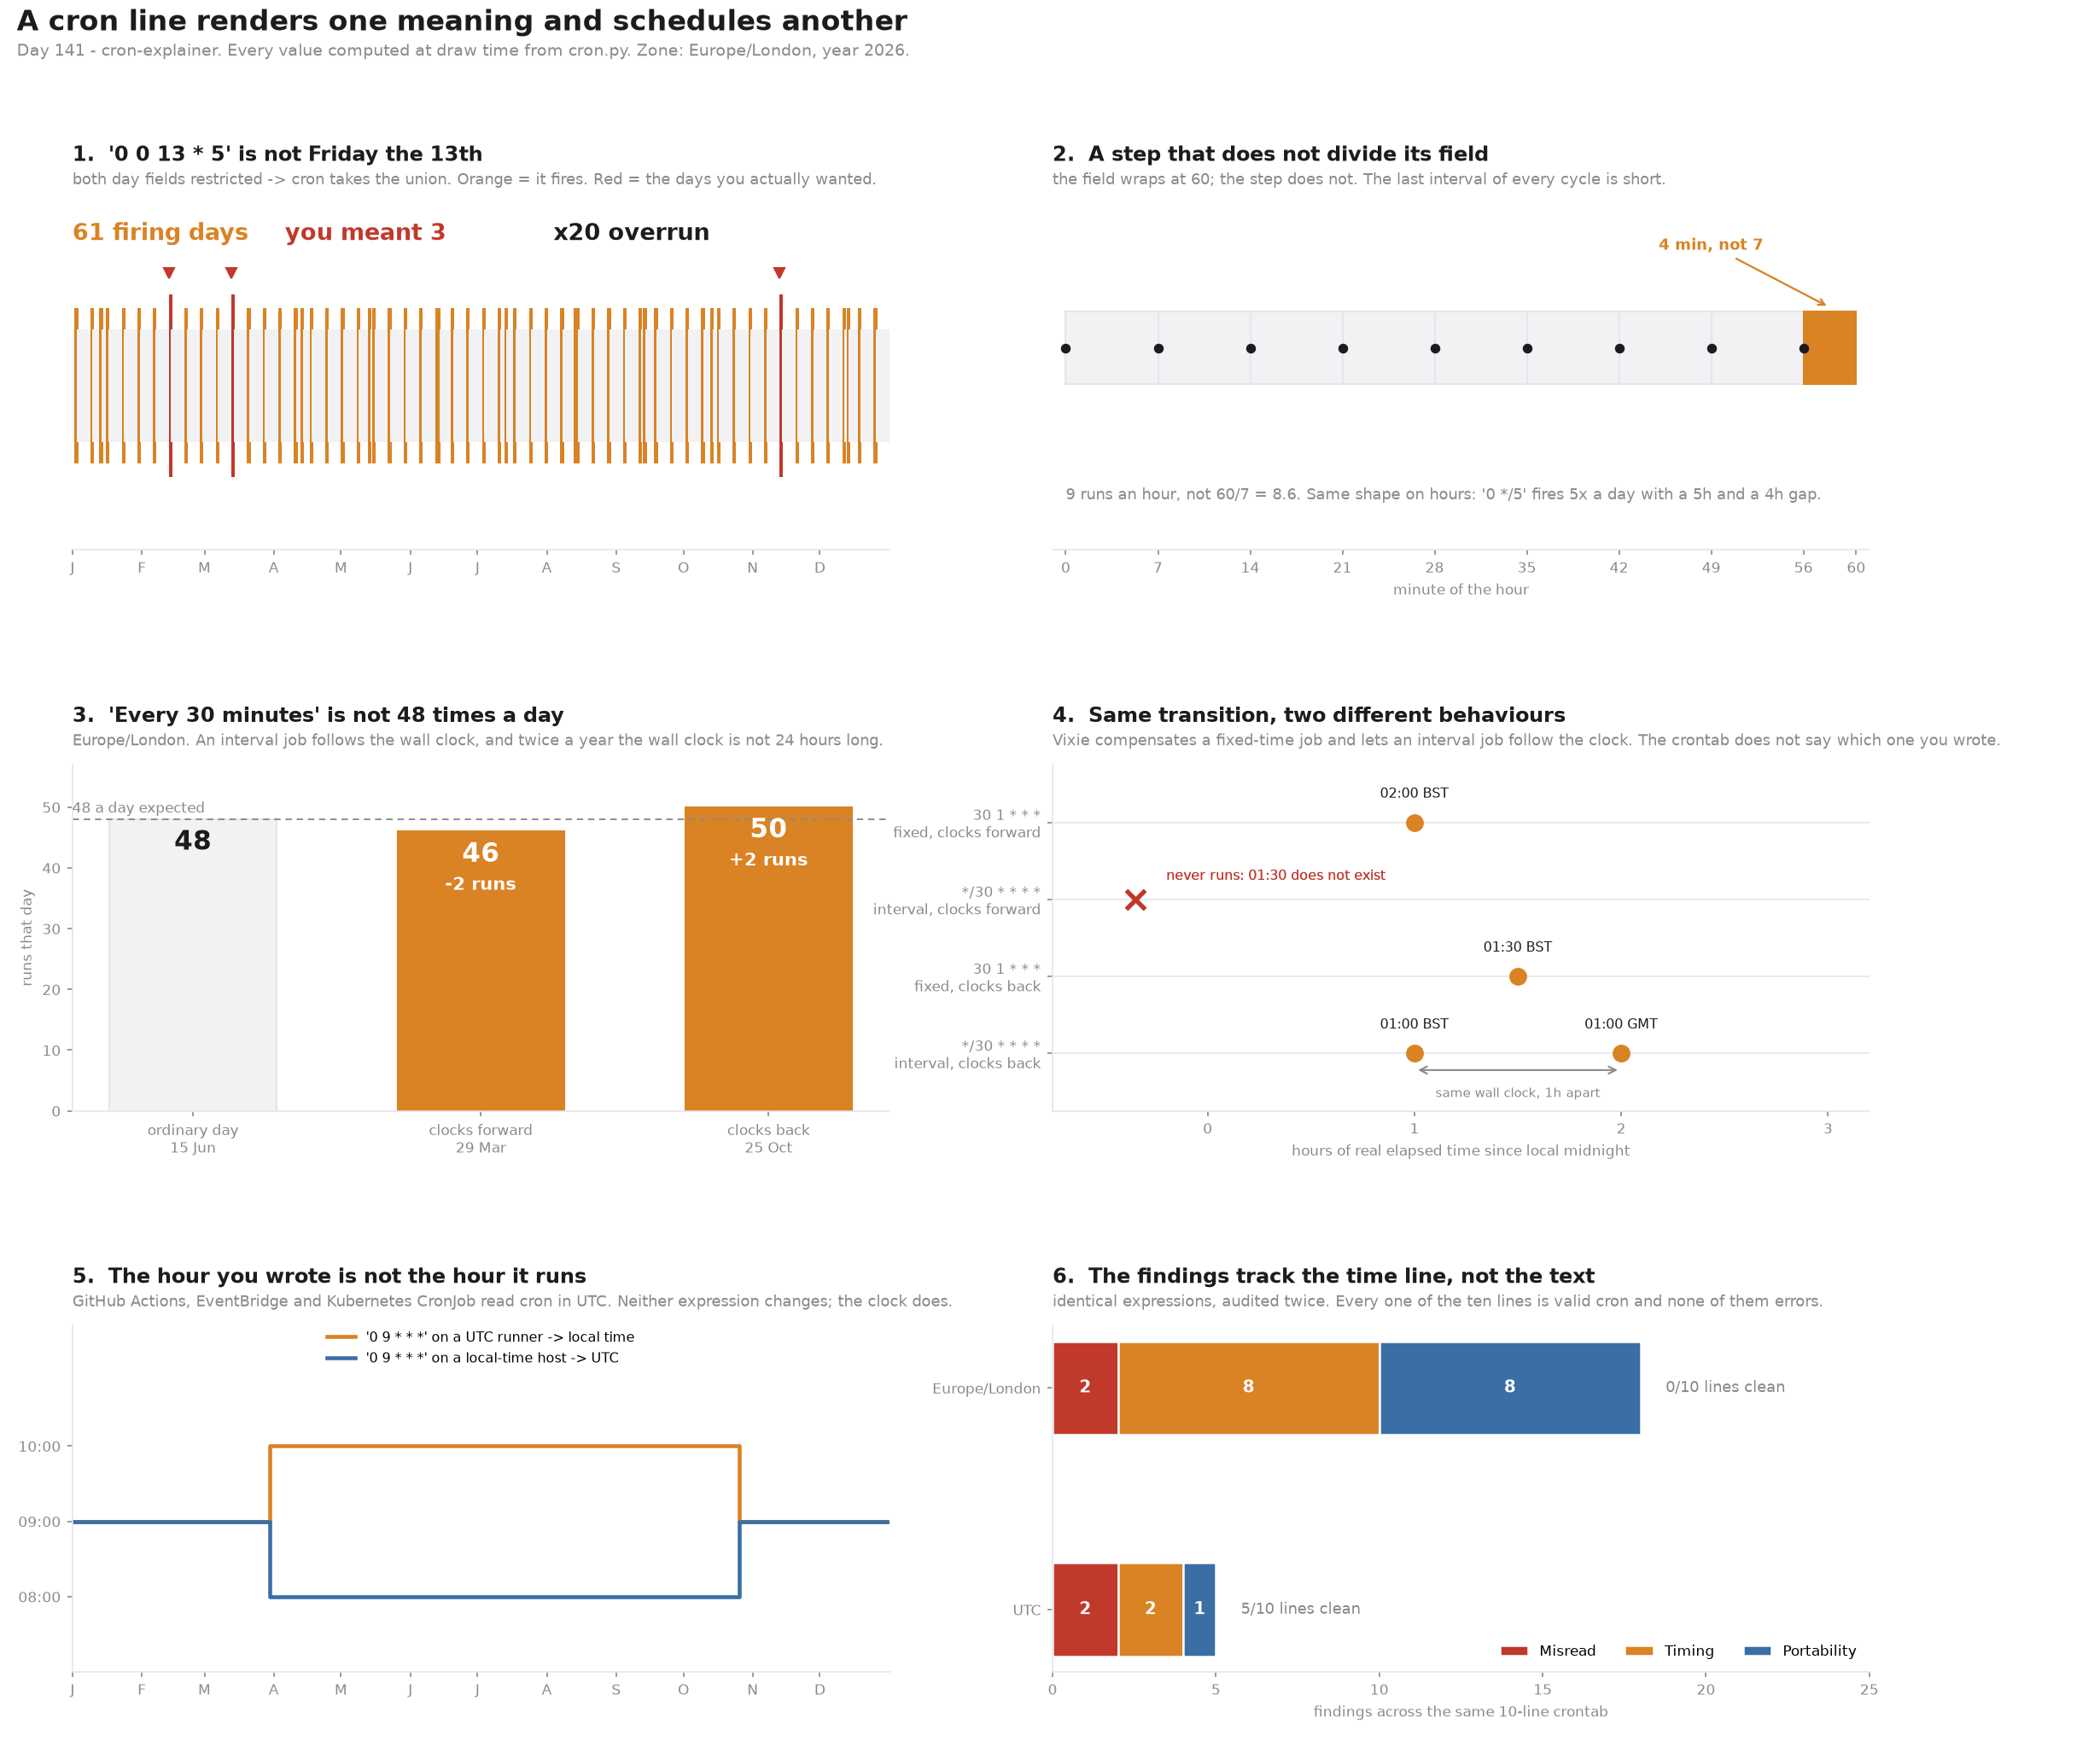

In [10]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

try:
    import make_chart
    make_chart.main("cron_audit_nb.png")
    from IPython.display import Image, display
    display(Image("cron_audit_nb.png"))
except Exception as exc:
    print("chart skipped:", exc)

## The findings track the time line, not the text

The same ten-line crontab, audited twice against different zones. If the counts
move, the audit is reading the schedule rather than pattern-matching the string.

In [11]:
SAMPLE = [
    ("0 0 13 * 5", "monthly close report, 'Friday the 13th'"),
    ("30 1 * * *", "nightly warehouse load"),
    ("*/7 * * * *", "queue drain, 'every 7 minutes'"),
    ("0 */5 * * *", "cache warm, 'every 5 hours'"),
    ("*/30 * * * *", "heartbeat"),
    ("0 9 * * 1-5", "weekday standup digest"),
    ("0 0 31 2 *", "quarter-end sweep"),
    ("0 3 * * 7", "weekly vacuum, 'Sunday'"),
    ("0 0 1 * *", "invoice run"),
    ("15 2 * * *", "backup rotate"),
]

for zone in ("Europe/London", "UTC"):
    total = clean = 0
    for e, _ in SAMPLE:
        fs = C.audit(C.parse(e), zone, start)
        total += len(fs)
        clean += not fs
    print(f"{zone:<16} {total:>3} findings, {clean}/{len(SAMPLE)} lines clean")

print("\nthe text did not change; the zone did\n")
print(f"{'expression':<15} {'findings'}")
print("-" * 62)
for e, _ in SAMPLE:
    codes = ", ".join(f.code for f in C.audit(C.parse(e), "Europe/London", start))
    print(f"{e:<15} {codes or '-'}")
print("-" * 62)
print("Every one of these ten lines is valid cron. None of them errors.")

Europe/London     18 findings, 0/10 lines clean
UTC                5 findings, 5/10 lines clean

the text did not change; the zone did

expression      findings
--------------------------------------------------------------
0 0 13 * 5      DOM_DOW_UNION, UTC_DRIFT
30 1 * * *      DST_SKIPPED, DST_REPEATED, UTC_DRIFT
*/7 * * * *     STEP_WRAP_GAP, DST_SKIPPED, DST_REPEATED
0 */5 * * *     STEP_WRAP_GAP
*/30 * * * *    DST_SKIPPED, DST_REPEATED
0 9 * * 1-5     UTC_DRIFT
0 0 31 2 *      NEVER_FIRES, UTC_DRIFT
0 3 * * 7       UTC_DRIFT, DOW_DIALECT
0 0 1 * *       UTC_DRIFT
15 2 * * *      UTC_DRIFT
--------------------------------------------------------------
Every one of these ten lines is valid cron. None of them errors.


## Try your own

Paste a line from a real crontab and a zone you actually deploy to.

In [12]:
# MY_EXPR = "0 2 1 * 0"        # <- your line
# MY_ZONE = "America/New_York"  # <- the zone the host keeps
#
# mine = C.parse(MY_EXPR)
# print(C.describe(mine), "\n")
# for f in C.audit(mine, MY_ZONE, start):
#     print(f"[{f.severity}] {f.code}: {f.message}")
#     if f.detail:
#         print(f"        {f.detail}")
# print()
# for f in C.fires(mine, datetime.now(), 8, MY_ZONE):
#     when = f"{f.instant:%Y-%m-%d %H:%M UTC}" if f.instant else "never runs"
#     print(f"  wall {f.local:%Y-%m-%d %H:%M} -> {when}  {f.note}")
pass

## Running it as an app

```bash
pip install -r requirements.txt
streamlit run app.py
```

Tests, including the two-algorithm cross-check:

```bash
python3 -m pytest test_cron.py -q
```

---

**Day 141** of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) -
[cron-explainer](automation-suite/cron-explainer). Part of the Automation Suite.